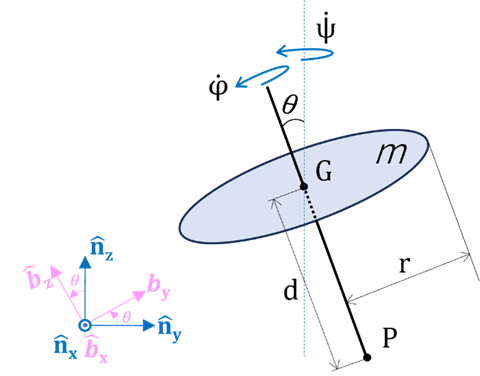

The figure above shows a Lagrange top of radius $\text{r}$ and mass $\text{m}$ whose bottom stem is fixed at one point $\text{P}$ on the floor. The distance between the top's mass center $\text{G}$ and $\text{P}$ is $\text{d}$. Two reference frames are defined to form equations of motion. One is a Newtonian frame denoted $\text{N}$ and the other is a body frame $\text{B}$. Both frames are associated each other with Euler angles ($\psi, \theta, \phi$) following the ZXZ convention. The top is has principal moment of inertia $I_3$​ about its symetrical axis and $I_1$​ about other principal axes perpendicular to the symetrical axis. The cell [2] below defines necessary SymPy symbols, reference frames and objects. 

In [1]:
%matplotlib widget
from sympy import symbols, cos, sin, lambdify, trigsimp, solve
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from sympy.physics.mechanics import ReferenceFrame, Point, inertia, RigidBody
from sympy.physics.mechanics import Lagrangian, LagrangesMethod
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.animation import FuncAnimation
init_vprinting()

In [2]:
# mass, radius, distance between mass center and floor, gravity acceleration, time 
m, r, d, g, t = symbols('m r d g t')
# principal moments of inertia of the top 
I_1, I_3 = symbols('I_1 I_3' )
# angular momenta conserved
P_phi, P_psi = symbols('P_phi P_psi')
# defining dynamic symbols to express Euler's angles
# precession
psi = dynamicsymbols('psi')
psi_dot = dynamicsymbols('psi',1) 
#nutation
theta = dynamicsymbols('theta')
theta_dot = dynamicsymbols('theta',1) 
theta_ddot = dynamicsymbols('theta',2)
# spin
phi = dynamicsymbols('phi')
phi_dot = dynamicsymbols('phi',1) 
#defining reference frames
N = ReferenceFrame('N') # Inertial frame
B = ReferenceFrame('B') # Body frame
# defining an Euler angle 3-1-3 set
B.orient_body_fixed(N, (psi, theta, phi), 'ZXZ')
# top's geometry
P= Point('P') #contact point 
CM = P.locatenew('CM', d*B.z) #tops's center of mass
P.set_vel(N,0) # setting the point P's velocity equal to zero

The Lagrange top is a standard textbook example on mechanics and there is no need to get into the nitty-gritty of EOM derivation here. With the codes in the cell [3] it is easy to have the Lagrangian: 
$$\mathcal{L}=\frac{I_1}{2}(\sin^2\theta\,\dot{\psi}+\dot{\theta}^2)+\frac{I_3}{2}(\dot{\phi}+\cos\theta\,\dot{\psi})^2-dgm\cos\theta \tag{1}$$
The codes are self-explanatory but if you are not familiar with SymPy please refer to the SymPy API reference [1].

In [3]:
J=inertia(B,I_1,I_1,I_3) # inersia tensor
BT = RigidBody('BT', CM, B, m, (J, P))# defining rigid body
BT.potential_energy = m*g*d*cos(theta) # defining potential energy of the top
L = Lagrangian(N, BT).simplify() # defining Lagrangian
L

From Lagrange's equations, we notice that there are two quantities that are conserved, namely $\displaystyle \frac{d}{dt} \left(\frac{\partial \mathcal{L}}{\partial \dot{\psi}}\right)=0$ and $\displaystyle\frac{d}{dt} \left(\frac{\partial \mathcal{L}}{\partial \dot{\phi}}\right)=0$. Following conventions in various textbooks and lecture notes [2] [3] [4], constants of motion are defined as follows:
$$
\begin{align}
P_\phi=&\frac{\partial \mathcal{L}}{\partial \dot{\phi}}=I_3(\dot{\phi}+\cos\theta\dot{\psi})\tag{2}\\
P_\psi=&\frac{\partial \mathcal{L}}{\partial \dot{\psi}}=(I_1\sin^2\theta+I_3\cos^2\theta)\,\dot{\psi}+I_3\cos\theta\,\dot{\phi}\tag{3}\\
\end{align}
$$
which are constant and to be calcurated with initial values for $\theta$, $\dot{\psi}$ and $\dot{\phi}$. 

If we solve the system of equations (2) and (3) for both $\dot{\psi}$ and $\dot{\phi}$, we get:  
$$
\begin{align}
\dot{\psi}=&\frac{1}{I_1\sin^2\theta}\left(P_\psi-P_\phi\cos\theta\right)\tag{4}\\
\dot{\phi}=&\frac{P_\phi}{I_3}-\frac{\cos\theta}{I_1\sin^2\theta}\left(P_\psi-P_\phi\cos\theta\right)\tag{5}\\
\end{align}
$$


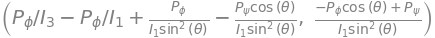

In [4]:
# defining constants of motion
P0=P_psi-L.diff(psi_dot)
P1=P_phi-L.diff(phi_dot)
# getting symbolic equations for psi_dot and phi_dot
P_sol=solve([P0,P1],[psi_dot,phi_dot])
phi_dot_=P_sol[phi_dot].simplify()
psi_dot_=P_sol[psi_dot].simplify()
phi_dot_, psi_dot_

As for the Lagrangian equation for $\ddot{\theta}$, we can directly calcurate the following with Sympy code given in the cell [5] 
$$ \frac{d}{dt} \left(\frac{\partial \mathcal{L}}{\partial \dot{\theta}}\right)-\frac{\partial \mathcal{L}}{\partial \theta} =0 \tag{6}$$
or obtain a set of Lagrangian equations given in the cell [6] and take the first equation for $\ddot{\theta}$, and we get:

$$I_1\ddot{\theta}+(I_3-I_1)\sin\theta\cos\theta\, \dot{\psi}^2 + I_3\sin\theta\,\dot{\phi}\,\dot{\psi}-dgm\sin\theta=0\tag{7}$$

In [5]:
L.diff(theta_dot).diff(t)-L.diff(theta)

In [6]:
LM = LagrangesMethod(L, [theta, psi, phi])
LE=LM.form_lagranges_equations()
LE

⎡                                    2                            2            ↪
⎢                - I₁⋅sin(θ)⋅cos(θ)⋅ψ̇  + I₁⋅θ̈ + I₃⋅sin(θ)⋅cos(θ)⋅ψ̇  + I₃⋅sin(θ ↪
⎢                                                                              ↪
⎢      2                                       2                               ↪
⎢I₁⋅sin (θ)⋅ψ̈ + 2⋅I₁⋅sin(θ)⋅cos(θ)⋅ψ̇⋅θ̇ - I₃⋅sin (θ)⋅ψ̈ - 2⋅I₃⋅sin(θ)⋅cos(θ)⋅ψ̇⋅θ̇ ↪
⎢                                                                              ↪
⎣                                       -I₃⋅sin(θ)⋅ψ̇⋅θ̇ + I₃⋅cos(θ)⋅ψ̈ + I₃⋅φ̈    ↪

↪                                      ⎤
↪ )⋅φ̇⋅ψ̇ - d⋅g⋅m⋅sin(θ)                 ⎥
↪                                      ⎥
↪                                      ⎥
↪  - I₃⋅sin(θ)⋅φ̇⋅θ̇ + I₃⋅cos(θ)⋅φ̈ + I₃⋅ψ̈⎥
↪                                      ⎥
↪                                      ⎦

Now we have a set of equations for numerical integration comprising (4), (5) and (7). To obtain numerical solutions with the ODEINT package with state variables: $y=[\theta, \dot{\theta},\dot{\psi},\dot{\phi}]$, "lamdification" of the symbolic equations will follow. The codes given below follow a standard procedure to numerically solve ordinary differential equaitons with PDEINT.

In [7]:
#  Physical parameters
_m = 8/1000                   # kg
_g = 9.81                     # m/s^2
_r = 20/1000                  # m
_I_1 = 1/4*_m*_r**2           # kg-m^2
_I_3 = 1/2*_m*_r**2           # kg-m^2
_d = 20/1000                  # m

# Initial conditions
psi_dot0 = 0.01               # rad/s
theta_dot0 = 0.01             # rad/s
phi_dot0 = 20*(2*np.pi)       # rad/s
psi_0 = 0.0                   # rad
theta_0 = np.pi/6             # rad
phi_0 = 0.0                   # rad
y00=[psi_0, phi_0, theta_0, theta_dot0]

# constants of motion
_P_psi= (_I_1*sin(theta_0)**2+_I_3*cos(theta_0)**2)*psi_dot0+_I_3*cos(theta_0)*phi_dot0
_P_phi= _I_3*(phi_dot0+cos(theta_0)*psi_dot0)

# rearrange the Lagrange equation for theta_ddot
EOM = solve([LE[0]], (theta_ddot))
theta_ddot = EOM[theta_ddot].trigsimp()

# symbols for constants are replaced with numbers
_psi_dot = psi_dot_.subs([(I_1,_I_1),(P_psi,_P_psi),(P_phi,_P_phi)])
_theta_ddot = theta_ddot.subs([(m,_m), (d,_d,), (g,_g), (I_1,_I_1), (I_3,_I_3)])
_phi_dot = phi_dot_.subs([(I_1,_I_1), (I_3,_I_3),(P_psi,_P_psi),(P_phi,_P_phi)])

# lamdify the angular velocity expressed in the Euler angles for numerical calculation
theta_ddot_f = lambdify((theta, psi_dot, phi_dot), _theta_ddot, "numpy")
psi_dot_f = lambdify((theta), _psi_dot, "numpy")
phi_dot_f = lambdify((theta), _phi_dot, "numpy")

In [8]:
# Define a function for the odeint solver
def dSdt(S, t):
    psi_, phi_, theta_, theta_d = S
    psi_dt= psi_dot_f(theta_)
    phi_dt=phi_dot_f(theta_)
    return [
        psi_dt,
        phi_dt,
        theta_d,
        theta_ddot_f(theta_, psi_dt, phi_dt),
    ]
# time span   
t = np.linspace(0, 2, 1000)
# solve the differential equation  
ans = odeint(dSdt, y0=y00, t=t)
psi_t = ans.T[0]
the_t = ans.T[2]
phi_t = ans.T[1]

The top consists of a line segment that corresponds to the rotating axis and a circular body. Point objects for the top are created to express the top's mass center, bottom and top ends each to be connected with line segments. To visualize spinning of the top, three other radius segments are added on a circular disk each spaced 60 degrees apart. The cicular disk consists of 20 circumferential line segements. All these objects are 3D whose coordinates can be easily calculated by SymPy and lamdified in the N reference frame for 3D animation.

In [9]:
# top's graphical configuration
T = Point('T') #top's upper end
E0 = Point('E0') #top's edge 0
E1= Point('E1') #top's edge 1
E2= Point('E2') #top's edge 2
cmt = 30/1000.0 # distance from center of mass to top's top
# defining point object's position
T.set_pos(CM, cmt*B.z)
E0.set_pos(CM, _r*B.x)
E1.set_pos(CM,_r*np.cos(2*np.pi/3)*B.x+_r*np.sin(2*np.pi/3)*B.y)
E2.set_pos(CM,_r*np.cos(-2*np.pi/3)*B.x+_r*np.sin(-2*np.pi/3)*B.y)

# creating point coordinates in the N-frame
coordinates = P.pos_from(P).to_matrix(N) 
for point in [CM, T, E0, E1, E2]:
    coordinates = coordinates.row_join(point.pos_from(P).to_matrix(N))
_coordinates = coordinates.subs([(d,_d)])
eval_point_coords = lambdify([psi,theta,phi], _coordinates)
# define function to calcurate the disk's circumferential point coordinates
spin_edge = E0.pos_from(P).to_matrix(N)
_spin_edge = spin_edge.subs([(d,_d)])
spin_edge_f = lambdify([psi,theta,phi], _spin_edge)

# 3-D circle line segments to illustrate top's circular edge
def edge_circle(psi_,theta_):
    n_seg = 20 # number of line segments
    circle_coords=[]
    phi_s = np.linspace(0, 2*np.pi,n_seg)
    for ph in phi_s:
        temp=spin_edge_f(psi_,theta_,ph).flatten().tolist()
        circle_coords.append(temp)
    return circle_coords

In [ ]:
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(111, projection ='3d')

line_prop = {
    'color': 'black',
    'marker': 'o',
    'markerfacecolor': 'blue',
    'markersize': 2,
}
l= 50/1000

def animate(i):
    ax.cla()
    
    ax.set_aspect('equal')
    ax.set_xlim((-l, l))
    ax.set_ylim((-l, l))
    ax.set_zlim((0, 2*l))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')   
    x, y, z = eval_point_coords(psi_t[i],the_t[i],phi_t[i])
    lines_3d, = ax.plot(x[:3], y[:3], z[:3], **line_prop)
    verts0 = edge_circle(psi_t[i],the_t[i])
    ax.add_collection3d(Poly3DCollection([verts0],edgecolor='k', facecolor='#000080',alpha=0.5))
    lines_3d,= ax.plot([x[1],x[3]], [y[1],y[3]], [z[1],z[3]], color="k", alpha=0.5)
    lines_3d,= ax.plot([x[1],x[4]], [y[1],y[4]], [z[1],z[4]], color="k", alpha=0.5)
    lines_3d,= ax.plot([x[1],x[5]], [y[1],y[5]], [z[1],z[5]], color="k", alpha=0.5)
ani = FuncAnimation(fig, animate, len(t),interval=5)

## references

[1] https://docs.sympy.org/latest/modules/physics/mechanics/api/part_bod.html

[2] https://davidtong.org/pdfs/teaching/classical-dynamics/clas3.pdf

[3] https://ocw.mit.edu/courses/16-07-dynamics-fall-2009/99f271d601bb3d9d04e8b8ce0c73cb7a_MIT16_07F09_Lec30.pdf

[4] https://cooperrc.github.io/advanced-dynamics/model_results/spinning_top-nonlinear.html